In [4]:
import sys
from pathlib import Path

# notebook file -> parent folder (adjust parents[n] if needed)
repo_root = Path.cwd().resolve().parent
sys.path.insert(0, str(repo_root))

In [5]:
import yfinance as yf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [6]:
import yfinance as yf
import pandas as pd
from pathlib import Path
from typing import Callable
from quantix.data import download_stock_data, add_rolling_features

##define a class that represents a stock and has methods to download, load, and have a signal to buy or sell
## read up on pydantic and dataclasses to make this better

class Stock:
    def __init__(self, ticker: str, start: str, end: str, window: int = 20, path: str = "../data"):
        self.ticker = ticker
        self.start = start
        self.end = end
        df = download_stock_data(self.ticker, self.start, self.end, should_save=False)
        df["Return"] = df["Close"].pct_change()
        self.data = add_rolling_features(df, window)
        
        self.path = path
        print(f'Stock class initialized for ticker {ticker} with data path {path}')

    def plot_data(self, show_signal: bool = False):
        plt.figure(figsize=(14, 7))
        plt.plot(self.data.index, self.data["Return"], label="Return", color="blue")
        plt.plot(self.data.index, self.data["rolling_mean"], label="Rolling Mean", color="orange")
        plt.plot(self.data.index, self.data["rolling_std"], label="Rolling Std", color="red")
        
        # if show_signal:
        #     buy_signals = self.data[self.data["Signal"] == 1]
        #     sell_signals = self.data[self.data["Signal"] == -1]
        #     plt.scatter(buy_signals.index, buy_signals["Return"], label="Buy Signal", marker="^", color="green")
        #     plt.scatter(sell_signals.index, sell_signals["Return"], label="Sell Signal", marker="v", color="red")
        plt.title(f"{self.ticker} Returns and Rolling Mean")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.legend()
        plt.grid()
        plt.show()


In [7]:
ticker = "AAPL"
start = "2022-01-01"
end = "2023-03-01"
aapl = Stock("AAPL", start=start, end=end)

[*********************100%***********************]  1 of 1 completed

Data fetched successfully for ticker AAPL from 2022-01-01 to 2023-03-01.
Stock class initialized for ticker AAPL with data path ../data


In [8]:
aapl.data.head()

Price,Open,High,Low,Close,Volume,Return,rolling_mean,rolling_std
Date,,,,,,,,
2022-01-03,174.013387,178.955006,173.895967,178.103668,104487900,NaN,NaN,NaN
2022-01-04,178.710386,179.013730,175.275708,175.843262,99310400,-0.012692,NaN,NaN
2022-01-05,175.755193,176.303172,170.891858,171.165848,94537600,-0.026600,NaN,NaN
2022-01-06,168.993491,171.537695,167.956243,168.308517,96904000,-0.016693,NaN,NaN
2022-01-07,169.179402,170.402574,167.359321,168.474854,86709100,0.000988,NaN,NaN


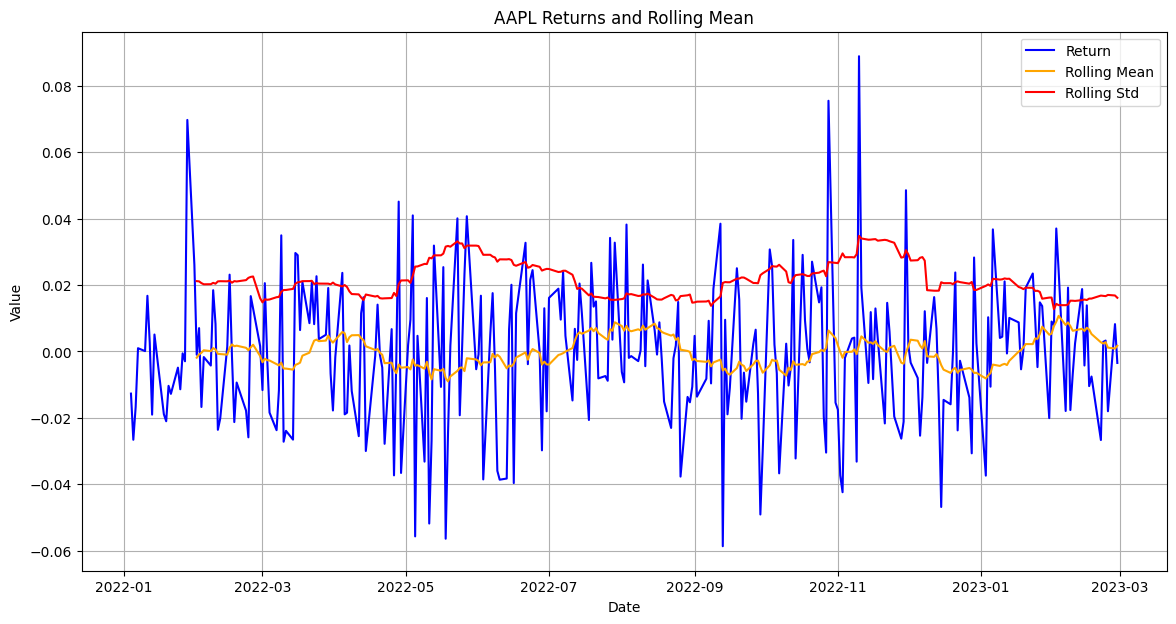

In [9]:
aapl.plot_data(show_signal=True)

## Key rule

Any strategy must implement generate_signal(row).

In [10]:
# class DummyStrategy:
#     def generate_signal(self, row):
#         return "SELL"

In [11]:
def z_score(row: dict) -> float:
    if row["rolling_std"] == 0:
        return 0
    return (row["Return"] - row["rolling_mean"]) / row["rolling_std"] if row["rolling_std"] != 0 else 0

def generate_signal(row: dict, threshold: float) -> int:
    if row["z_score"] < -threshold:
        return 1
    elif row["z_score"] > threshold:
        return -1
    return 0
    
class Z_Strategy:
    def __init__(self, stock: Stock, threshold:float = 2):
        self.stock = stock
        self.data = stock.data
        self.threshold = threshold
        # plot the z-score of the return with the rolling mean and std
        self.data["z_score"] = self.data.apply(z_score, axis=1)
        # Adir - make sure you understand lambda functions and the partial pattern here and why we need it
        self.data["signal"] = self.data.apply(lambda row: generate_signal(row, self.threshold), axis=1)
    
    def generate_signal(self, row):
        # refactor in future to use the z_score and threshold to generate signal
        # the apply should be part of backtest, not part of strategy since strat should generate 
        # signal per row (so can be used in backtest or live trading)
        pass     
    
    def plot_strategy(self):
        plt.figure(figsize=(14, 7))
        plt.plot(self.data.index, self.data["z_score"], label="Z-Score", color="purple")
        # add buy sell markers to graph
        buy_signals = self.data[self.data["signal"] == 1]
        sell_signals = self.data[self.data["signal"] == -1]
        plt.scatter(buy_signals.index, buy_signals["z_score"], label="Buy Signal", marker="^", color="green")
        plt.scatter(sell_signals.index, sell_signals["z_score"], label="Sell Signal", marker="v", color="red")

        plt.title(f"Z-Score of Returns")
        plt.xlabel("Date")
        plt.ylabel("Z-Score")
        plt.legend()
        plt.grid()
        plt.show()


In [12]:
strategy = Z_Strategy(aapl, threshold=2)

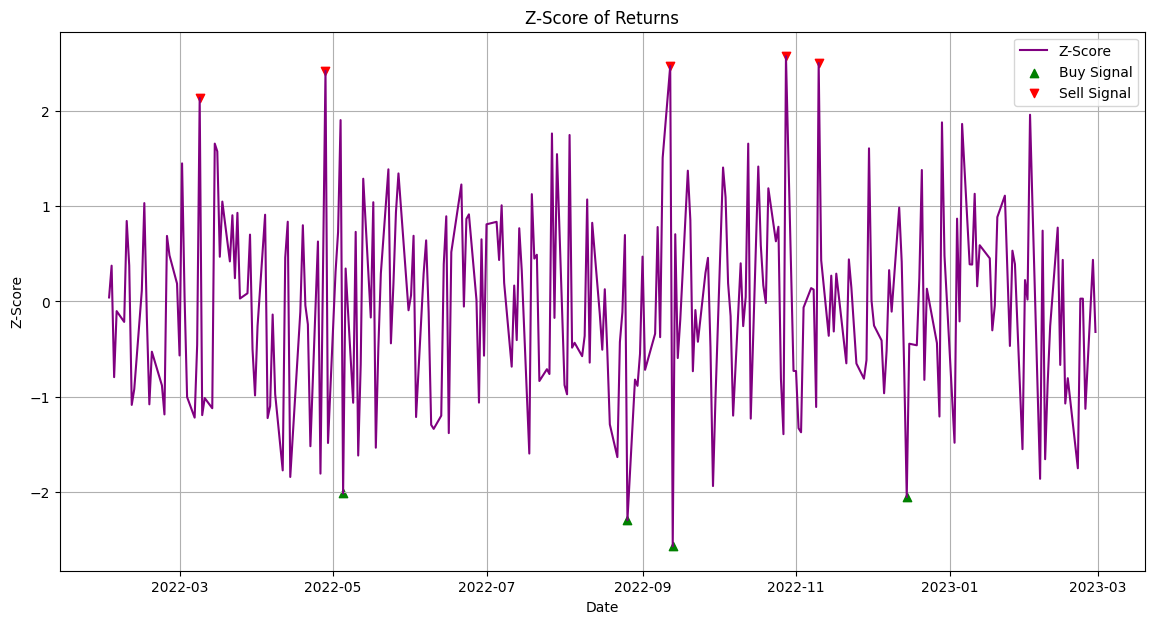

In [13]:
strategy.plot_strategy()

In [14]:
 ## now we want to make this a backtestable strategy, so we need to create a backtester class that takes in a strategy and a stock and runs the backtest, calculating the returns of the strategy and comparing it to a buy and hold strategy.

class Backtester:
    def __init__(self, strategy):
        self.strategy = strategy
        self.data = strategy.data
    
    def backtest(self):
        # calculate returns of strategy
        self.data["strategy_return"] = self.data["signal"].shift(1) * self.data["Return"]
        # calculate cumulative returns
        self.data["cumulative_strategy_return"] = (1 + self.data["strategy_return"]).cumprod() - 1
        self.data["cumulative_buy_and_hold_return"] = (1 + self.data["Return"]).cumprod() - 1
        
    def plot_backtest(self):
        plt.figure(figsize=(14, 7))
        plt.plot(self.data.index, self.data["cumulative_strategy_return"], label="Strategy Return", color="blue")
        plt.plot(self.data.index, self.data["cumulative_buy_and_hold_return"], label="Buy and Hold Return", color="orange")
        plt.title(f"Backtest of Strategy vs Buy and Hold")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid()
        plt.show()

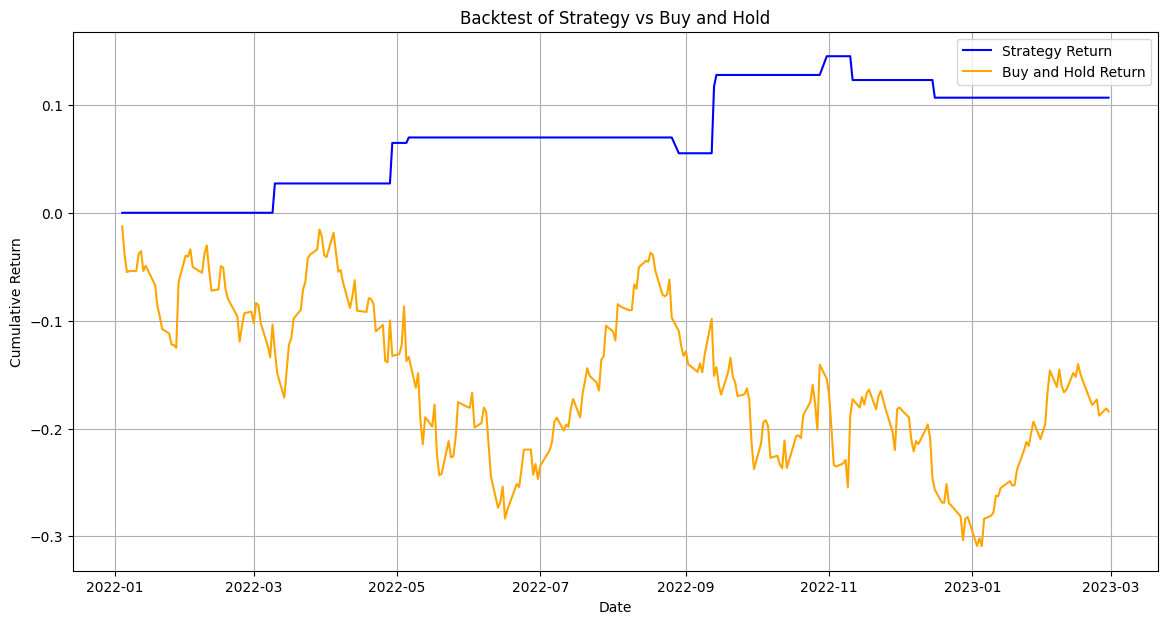

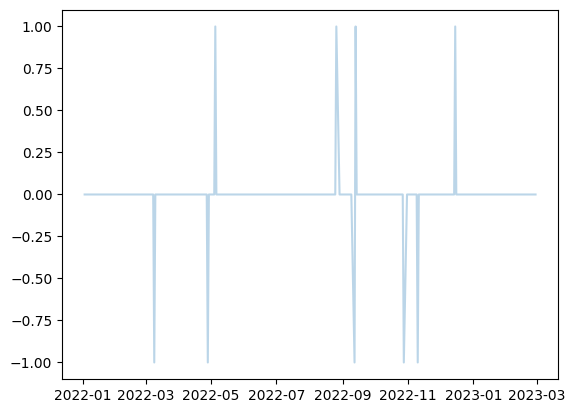

In [16]:
bt = Backtester(strategy)
bt.backtest()
bt.plot_backtest()

plt.plot(bt.data.index, bt.data["signal"], label="Signal", alpha=0.3)
# This helps visually connect when trades happen and how returns move


